In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [233]:
df_elec= pd.read_csv('/content/household_power_consumption.csv.zip')

In [234]:
df_elec.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [235]:
df_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [236]:
df_elec.replace('?', np.nan, inplace=True)
df_elec.dropna(inplace=True)

In [237]:
df_elec['timestamp'] = pd.to_datetime(df_elec['Date'] + ' ' + df_elec['Time'])

/tmp/ipykernel_9847/70452921.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_elec['timestamp'] = pd.to_datetime(df_elec['Date'] + ' ' + df_elec['Time'])


 Keep only important column

In [238]:


df_elec = df_elec[['timestamp', 'Global_active_power']]
df_elec.rename(columns={'Global_active_power': 'electricity_usage'}, inplace=True)



Convert to float

In [239]:

df_elec['electricity_usage'] = df_elec['electricity_usage'].astype(float)


Save clean electricity data

In [240]:

df_elec.to_csv("electricity_data.csv", index=False)

In [241]:

print("✅ Electricity dataset ready")

✅ Electricity dataset ready


In [242]:
df_elec.head()

,timestamp,electricity_usage
0,2006-12-16 17:24:00,4.216
1,2006-12-16 17:25:00,5.360
2,2006-12-16 17:26:00,5.374
3,2006-12-16 17:27:00,5.388
4,2006-12-16 17:28:00,3.666


MESS

In [243]:

hours = pd.date_range('2025-01-01', periods=8760, freq='H')

footfall = []

for t in hours:
    h = t.hour
    day = t.dayofweek

    if 0 <= h <= 5:
        base = np.random.randint(5, 20)       # night
    elif 6 <= h <= 10:
        base = np.random.randint(20, 50)      # morning
    elif 11 <= h <= 14:
        base = np.random.randint(80, 150)     # lunch peak
    elif 15 <= h <= 18:
        base = np.random.randint(40, 80)      # afternoon
    elif 19 <= h <= 21:
        base = np.random.randint(70, 130)     # dinner peak
    else:
        base = np.random.randint(30, 60)      # late evening


    if day >= 5:  # Saturday, Sunday
        base *= 0.7

    noise = np.random.randint(-10, 10)

    value = base + noise


    value = max(value, 0)

    footfall.append(value)



/tmp/ipykernel_9847/1175824978.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range('2025-01-01', periods=8760, freq='H')


In [244]:
df_mess = pd.DataFrame({
    'timestamp': hours,
    'mess_footfall': footfall
})

df_mess.to_csv("mess_data.csv", index=False)

print("✅ Mess dataset ready")


✅ Mess dataset ready


In [245]:
df_mess =pd.read_csv('/content/mess_data.csv')

In [246]:
df_mess.head()

,timestamp,mess_footfall
0,2025-01-01 00:00:00,26.0
1,2025-01-01 01:00:00,9.0
2,2025-01-01 02:00:00,3.0
3,2025-01-01 03:00:00,11.0
4,2025-01-01 04:00:00,25.0


In [247]:
df_mess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      8760 non-null   object 
 1   mess_footfall  8760 non-null   float64
dtypes: float64(1), object(1)
memory usage: 137.0+ KB


WIFI

In [248]:
wifi_usage = np.random.randint(50, 150, size=8760)





In [249]:

for i in range(len(hours)):
    h = hours[i].hour

    if 0 <= h <= 6:
        wifi_usage[i] *= 0.3
    elif 7 <= h <= 12:
        wifi_usage[i] *= 0.7
    elif 13 <= h <= 18:
        wifi_usage[i] *= 1.0
    else:
        wifi_usage[i] *= 1.3  # evening peak

In [250]:

wifi_usage += np.random.randint(-20, 20, size=8760)

In [251]:


spikes = np.random.choice(len(wifi_usage), 40)
wifi_usage[spikes] += np.random.randint(100, 300, size=40)

In [252]:
wifi_usage = np.maximum(wifi_usage, 0)
df['timestamp'] = pd.date_range(start='2025-01-01', periods=len(df), freq='H')

In [253]:
df_wifi = pd.DataFrame({
    'timestamp': hours,
    'wifi_usage': wifi_usage
})

df_wifi.to_csv("wifi_data.csv", index=False)

print("✅ WiFi dataset ready")

✅ WiFi dataset ready


In [254]:
df_wifi =pd.read_csv('/content/wifi_data.csv')

In [255]:
df_wifi.head()

,timestamp,wifi_usage
0,2025-01-01 00:00:00,0
1,2025-01-01 01:00:00,44
2,2025-01-01 02:00:00,9
3,2025-01-01 03:00:00,7
4,2025-01-01 04:00:00,18


ATTENDENCE

In [256]:
num_students = 500
dates = pd.date_range('2025-01-01', periods=180)





In [257]:
attendance_data = []

for date in dates:
    for student in range(num_students):
        attendance = np.random.choice([0, 1], p=[0.2, 0.8])  # 80% attendance
        attendance_data.append([date, student, attendance])

In [258]:
df_attendance = pd.DataFrame(attendance_data, columns=[
    'date', 'student_id', 'present'
])

In [259]:


df_attendance['day'] = pd.to_datetime(df_attendance['date']).dt.dayofweek

weekend = df_attendance['day'] >= 5

df_attendance.loc[weekend, 'present'] = np.random.choice(
    [0, 1],
    size=weekend.sum(),
    p=[0.4, 0.6]
)


In [260]:


df_attendance.to_csv("attendance_data.csv", index=False)

print("✅ Attendance dataset ready")


✅ Attendance dataset ready


In [261]:
df_attendance =pd.read_csv('/content/attendance_data.csv')

In [262]:
df_attendance.head()

,date,student_id,present,day
0,2025-01-01,0,1,2
1,2025-01-01,1,1,2
2,2025-01-01,2,1,2
3,2025-01-01,3,1,2
4,2025-01-01,4,0,2


In [263]:
df_attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        90000 non-null  object
 1   student_id  90000 non-null  int64 
 2   present     90000 non-null  int64 
 3   day         90000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ MB


EDA

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns

In [265]:
df_mess['timestamp'] = pd.to_datetime(df_mess['timestamp'])
df_wifi['timestamp'] = pd.to_datetime(df_wifi['timestamp'])
df_elec['timestamp'] = pd.to_datetime(df_elec['timestamp'])

In [266]:
for df in [df_mess, df_wifi, df_elec]:
    df['hour'] = df['timestamp'].dt.hour
    df['day'] = df['timestamp'].dt.day
    df['month'] = df['timestamp'].dt.month
    df['dayofweek'] = df['timestamp'].dt.dayofweek

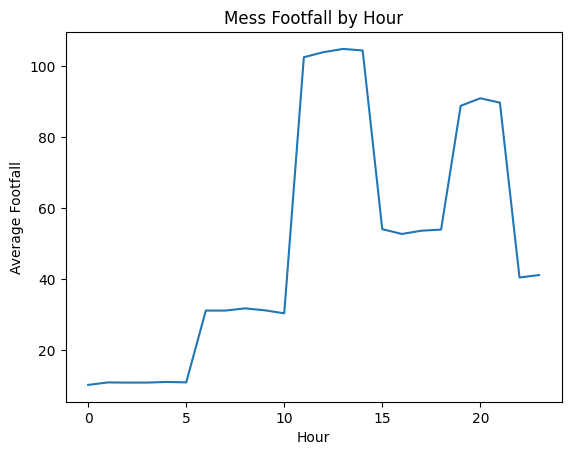

In [267]:
mess_hour = df_mess.groupby('hour')['mess_footfall'].mean()

import matplotlib.pyplot as plt

plt.figure()
plt.plot(mess_hour)
plt.title("Mess Footfall by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Footfall")
plt.show()

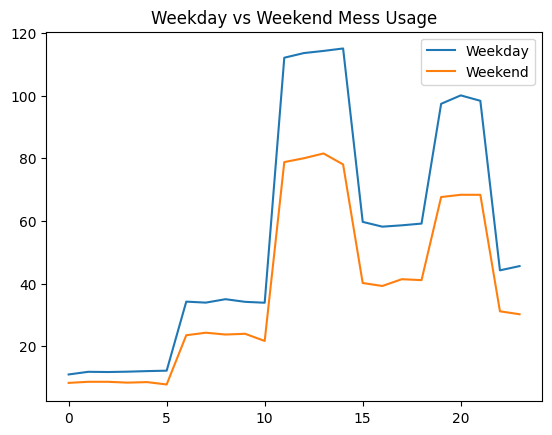

In [268]:
weekday = df_mess[df_mess['dayofweek'] < 5]
weekend = df_mess[df_mess['dayofweek'] >= 5]

plt.figure()
plt.plot(weekday.groupby('hour')['mess_footfall'].mean(), label='Weekday')
plt.plot(weekend.groupby('hour')['mess_footfall'].mean(), label='Weekend')
plt.legend()
plt.title("Weekday vs Weekend Mess Usage")
plt.show()

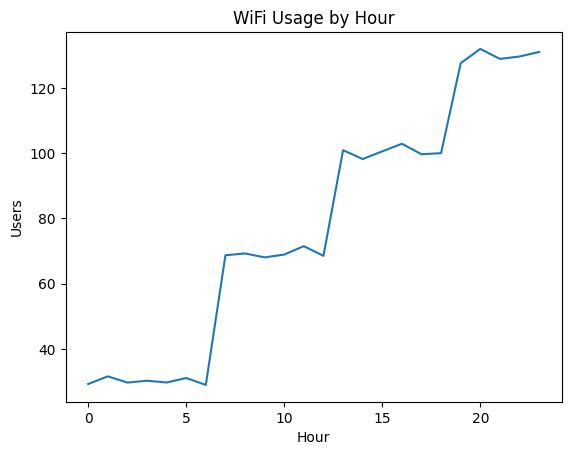

In [269]:
wifi_hourly = df_wifi.groupby('hour')['wifi_usage'].mean()

plt.figure()
plt.plot(wifi_hourly)
plt.title("WiFi Usage by Hour")
plt.xlabel("Hour")
plt.ylabel("Users")
plt.show()

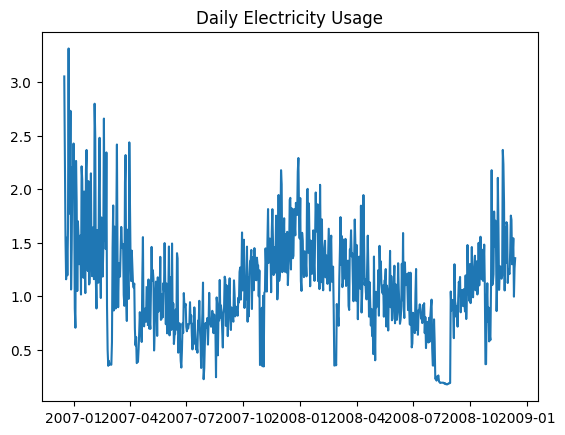

In [270]:
elec_daily = df_elec.resample('D', on='timestamp')['electricity_usage'].mean()

plt.figure()
plt.plot(elec_daily)
plt.title("Daily Electricity Usage")
plt.show()

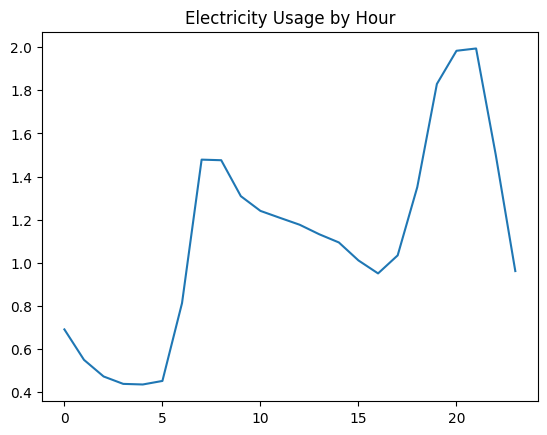

In [271]:
elec_hourly = df_elec.groupby('hour')['electricity_usage'].mean()

plt.figure()
plt.plot(elec_hourly)
plt.title("Electricity Usage by Hour")
plt.show()

here we have done EDA and understood all the patterns

In [272]:
df_combined['mess_footfall'] = pd.to_numeric(df_combined['mess_footfall'], errors='coerce')
df_combined['wifi_usage'] = pd.to_numeric(df_combined['wifi_usage'], errors='coerce')

print(df_combined[['mess_footfall','wifi_usage']].corr())

               mess_footfall  wifi_usage
mess_footfall       1.000000    0.461841
wifi_usage          0.461841    1.000000


In [273]:
print(df_combined[['mess_footfall','wifi_usage']].dtypes)

mess_footfall    float64
wifi_usage         int64
dtype: object


In [274]:
df_combined[['mess_footfall', 'wifi_usage']].isna().sum()

,0
mess_footfall,0
wifi_usage,0


In [275]:
print(df_combined[['mess_footfall','wifi_usage']].head(10))

   mess_footfall  wifi_usage
0           15.0          30
1           15.0          38
2            4.0          42
3            0.0          50
4           16.0          31
5            5.0          42
6           36.0          28
7           30.0          71
8           45.0          88
9           25.0          73


In [276]:
print(df_combined[['mess_footfall','wifi_usage']].corr())

               mess_footfall  wifi_usage
mess_footfall       1.000000    0.461841
wifi_usage          0.461841    1.000000


In [277]:
attendance_rate = df_attendance['present'].mean()
print("Attendance Rate:", attendance_rate)

Attendance Rate: 0.7422222222222222


In [278]:
print(df_mess.describe())
print(df_wifi.describe())
print(df_elec.describe())

                 timestamp  mess_footfall         hour          day  \
count                 8760    8760.000000  8760.000000  8760.000000   
mean   2025-07-02 11:30:00      50.113653    11.500000    15.720548   
min    2025-01-01 00:00:00       0.000000     0.000000     1.000000   
25%    2025-04-02 05:45:00      19.000000     5.750000     8.000000   
50%    2025-07-02 11:30:00      41.400000    11.500000    16.000000   
75%    2025-10-01 17:15:00      75.000000    17.250000    23.000000   
max    2025-12-31 23:00:00     158.000000    23.000000    31.000000   
std                    NaN      37.450155     6.922582     8.796749   

             month    dayofweek  
count  8760.000000  8760.000000  
mean      6.526027     2.997260  
min       1.000000     0.000000  
25%       4.000000     1.000000  
50%       7.000000     3.000000  
75%      10.000000     5.000000  
max      12.000000     6.000000  
std       3.448048     1.998056  
                 timestamp   wifi_usage         hour  

MACHINE LEARNING :we will mostly apply random forest to train our data

In [279]:
df_combined = df_mess.merge(df_wifi, on='timestamp')


df_combined['hour'] = df_combined['timestamp'].dt.hour
df_combined['dayofweek'] = df_combined['timestamp'].dt.dayofweek


X = df_combined[['hour', 'dayofweek']]
y = df_combined['mess_footfall']

In [330]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test_mess, y_train, y_test_mess = train_test_split(X, y, test_size=0.2)


model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [331]:
y_pred_mess = model.predict(X_test_mess)

In [332]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test_mess, y_pred_mess))

MAE: 10.250637608027253


In [333]:
mae = mean_absolute_error(y_test_mess, y_pred_mess)
mean_val = y.mean()

print("MAE:", mae)
print("Relative Error (%):", (mae/mean_val)*100)

MAE: 10.250637608027253
Relative Error (%): 20.45478028625315


In [334]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [335]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [336]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [338]:
y_pred_mess = model.predict(X_test_mess)

In [339]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test_mess, y_pred_mess))

MAE: 10.250881561330518


In [340]:
lower = df_mess['mess_footfall'].mean() - 2*df_mess['mess_footfall'].std()
upper = df_mess['mess_footfall'].mean() + 2*df_mess['mess_footfall'].std()

df_mess['anomaly'] = (df_mess['mess_footfall'] > upper) | (df_mess['mess_footfall'] < lower)

WIFI

In [317]:
X_wifi = df_combined[['hour', 'dayofweek', 'mess_footfall']]
y_wifi = df_combined['wifi_usage']


X_train, X_test_wifi, y_train, y_test_wifi = train_test_split(X_wifi, y_wifi, test_size=0.2)

model_wifi = RandomForestRegressor()
model_wifi.fit(X_train, y_train)

y_pred_wifi = model_wifi.predict(X_test_wifi)

from sklearn.metrics import mean_absolute_error
print("WiFi MAE:", mean_absolute_error(y_test_wifi, y_pred_wifi))

WiFi MAE: 25.71239793093132


FOR ELECTRICITY

In [320]:
X_elec = df_elec[['hour', 'dayofweek']]
y_elec = df_elec['electricity_usage']

X_train, X_test_elec, y_train, y_test_elec= train_test_split(X_wifi, y_wifi, test_size=0.2)

In [321]:
model_elec = RandomForestRegressor()
model_elec.fit(X_train, y_train)

RandomForestRegressor()

In [324]:
y_pred_elec = model_elec.predict(X_test_elec)
rf_mae = mean_absolute_error(y_test_elec, y_pred_elec)

print("Electricity MAE by RF :", rf_mae)

Electricity MAE by RF : 25.021421580084677


In [294]:
df_elec = df_elec.sort_values('timestamp')
df_elec.set_index('timestamp', inplace=True)

In [295]:
series = df_elec['electricity_usage']

In [296]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

In [297]:
df_elec_daily = df_elec.resample('D').mean()
series = df_elec_daily['electricity_usage']

In [298]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,1))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [299]:
predictions = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [308]:
from sklearn.metrics import mean_absolute_error

arima_mae = mean_absolute_error(test, predictions)
print("ARIMA MAE:", arima_mae)

ARIMA MAE: 0.7678868735004991


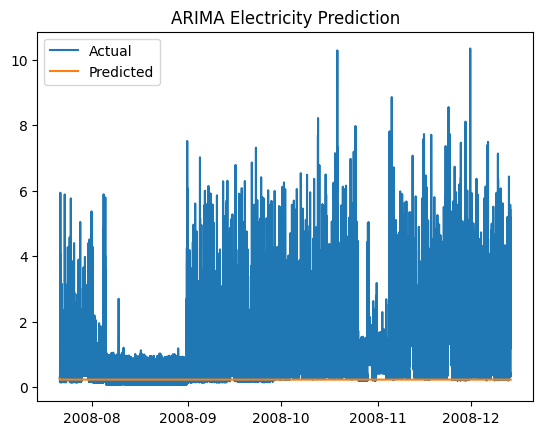

In [301]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted')
plt.legend()
plt.title("ARIMA Electricity Prediction")
plt.show()

In [312]:
print("RF MAE:", rf_mae)
print("ARIMA MAE:", arima_mae)

RF MAE: 26.1084856397091
ARIMA MAE: 0.7678868735004991


ATTENDANCE

In [341]:
from sklearn.ensemble import RandomForestClassifier

X_att = df_attendance[['day', 'student_id']]
y_att = df_attendance['present']

X_train, X_test_att, y_train, y_test_att = train_test_split(X_att, y_att, test_size=0.2)

model_att = RandomForestClassifier()
model_att.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred_att = model_att.predict(X_test_att)
print("Accuracy:", accuracy_score(y_test_att, y_pred_att))

Accuracy: 0.7351111111111112


In [342]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test_att, y_pred_att))

[[  393  4210]
 [  558 12839]]


R2 SCORE

In [318]:

r2_wifi = r2_score(y_test_wifi, y_pred_wifi)
print("WiFi R2 Score:", r2_wifi)

WiFi R2 Score: 0.42866274564732876


In [325]:
r2_elec_rf = r2_score(y_test_elec, y_pred_elec)
print("Electricity RF R2 Score:", r2_elec_rf)

Electricity RF R2 Score: 0.4654871516239443


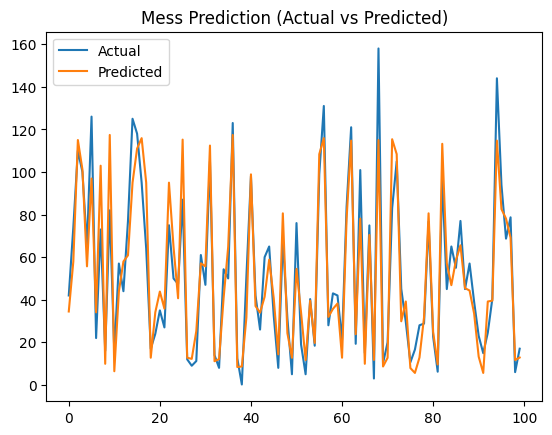

In [343]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test_mess.values[:100], label='Actual')
plt.plot(y_pred_mess[:100], label='Predicted')
plt.legend()
plt.title("Mess Prediction (Actual vs Predicted)")
plt.show()

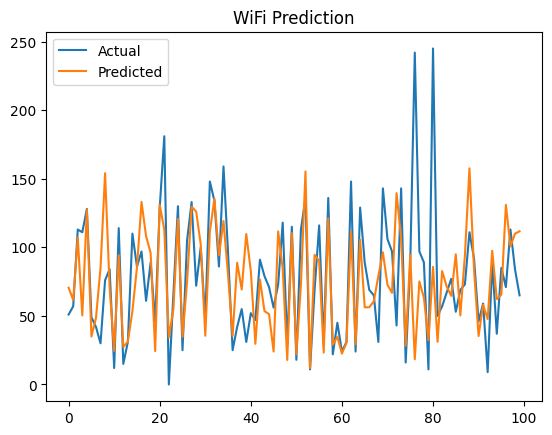

In [346]:
plt.figure()
plt.plot(y_test_wifi.values[:100], label='Actual')
plt.plot(y_pred_wifi[:100], label='Predicted')
plt.legend()
plt.title("WiFi Prediction")
plt.show()

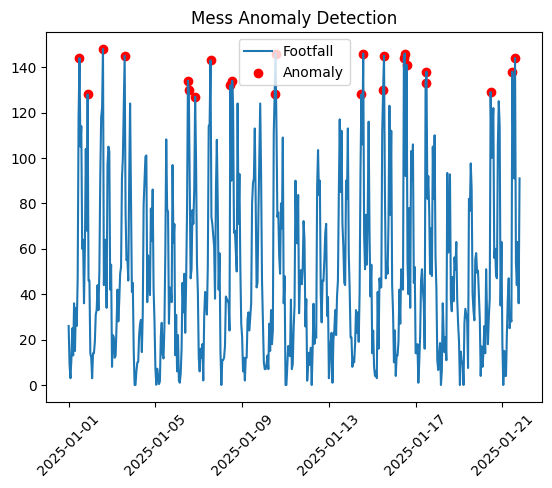

In [348]:
subset = df_mess.iloc[:500]

plt.figure()

# Line plot
plt.plot(subset['timestamp'], subset['mess_footfall'], label='Footfall')

# Only anomalies in this range
anomalies = subset[subset['anomaly'] == True]

plt.scatter(anomalies['timestamp'], anomalies['mess_footfall'],
            color='red', label='Anomaly')

plt.legend()
plt.title("Mess Anomaly Detection")
plt.xticks(rotation=45)
plt.show()

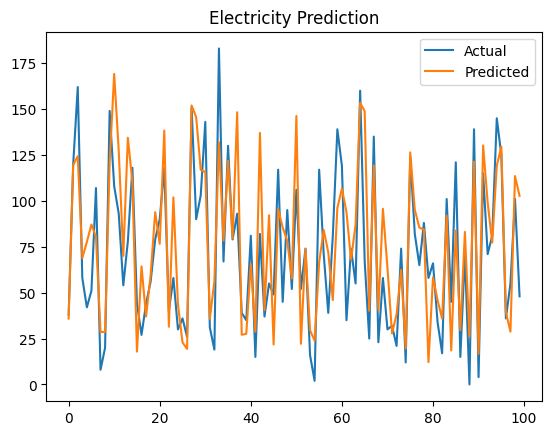

In [350]:
plt.figure()
plt.plot(y_test_elec.values[:100], label='Actual')
plt.plot(y_pred_elec[:100], label='Predicted')
plt.legend()
plt.title("Electricity Prediction")
plt.show()

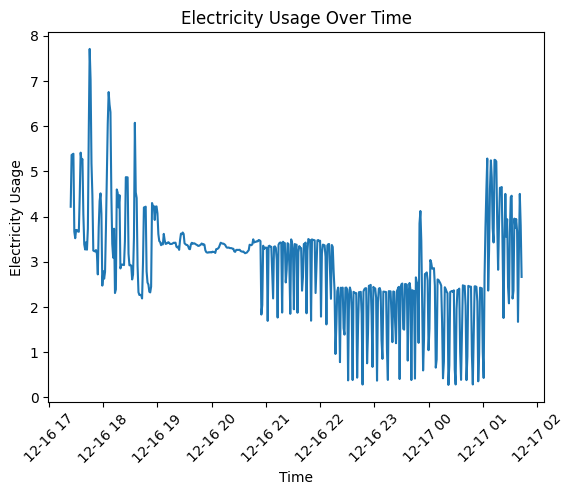

In [354]:
plt.figure()
plt.plot(df_elec.index[:500], df_elec['electricity_usage'][:500])
plt.xticks(rotation=45)
plt.xlabel("Time")
plt.ylabel("Electricity Usage")
plt.title("Electricity Usage Over Time")
plt.show()

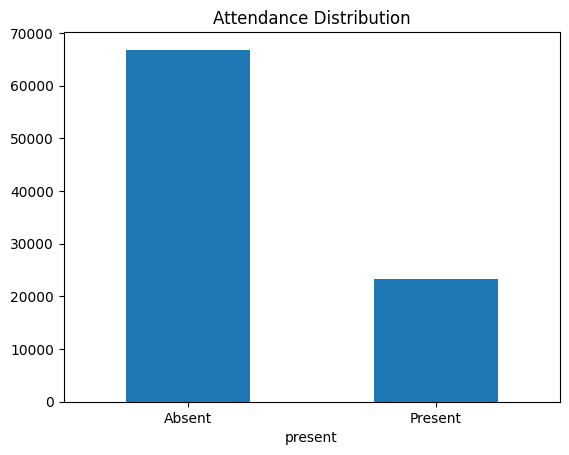

In [355]:
df_attendance['present'].value_counts().plot(kind='bar')
plt.title("Attendance Distribution")
plt.xticks([0,1], ['Absent','Present'], rotation=0)
plt.show()

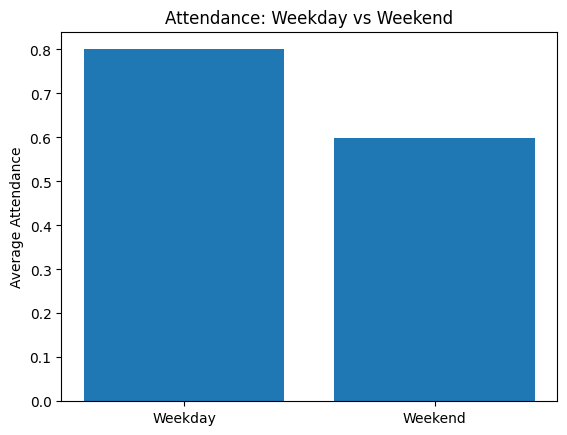

In [358]:
df_attendance['day'] = pd.to_datetime(df_attendance['date']).dt.dayofweek

weekday = df_attendance[df_attendance['day'] < 5]['present'].mean()
weekend = df_attendance[df_attendance['day'] >= 5]['present'].mean()

plt.bar(['Weekday','Weekend'], [weekday, weekend])
plt.title("Attendance: Weekday vs Weekend")
plt.ylabel("Average Attendance")
plt.show()